In [1]:
# PART 1 : IMPORT LIBRARIES

import os
import random
import warnings
import numpy as np

import torch
import torch.nn as nn

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch Version :", torch.__version__)
print("Device          :", DEVICE)

PyTorch Version : 2.11.0+cu128
Device          : cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATASET_PATH = "/content/drive/MyDrive"

In [6]:
# LOAD DATASET
X = np.load(os.path.join(DATASET_PATH, "NEW_ROI_X.npy"))
Y = np.load(os.path.join(DATASET_PATH, "NEW_ROI_Y.npy"))

print("Dataset loaded successfully!\n")

print(f"Images Shape : {X.shape}")
print(f"Masks Shape  : {Y.shape}")

Dataset loaded successfully!

Images Shape : (3242, 128, 128, 1)
Masks Shape  : (3242, 128, 128, 1)


In [8]:
print("Image Shape :", X.shape)
print("Mask Shape  :", Y.shape)

print("Image dtype :", X.dtype)
print("Mask dtype  :", Y.dtype)

print("Image Min/Max :", X.min(), X.max())
print("Mask Unique   :", np.unique(Y))

Image Shape : (3242, 128, 128, 1)
Mask Shape  : (3242, 128, 128, 1)
Image dtype : float32
Mask dtype  : uint8
Image Min/Max : 0.003921569 1.0000001
Mask Unique   : [0 1]


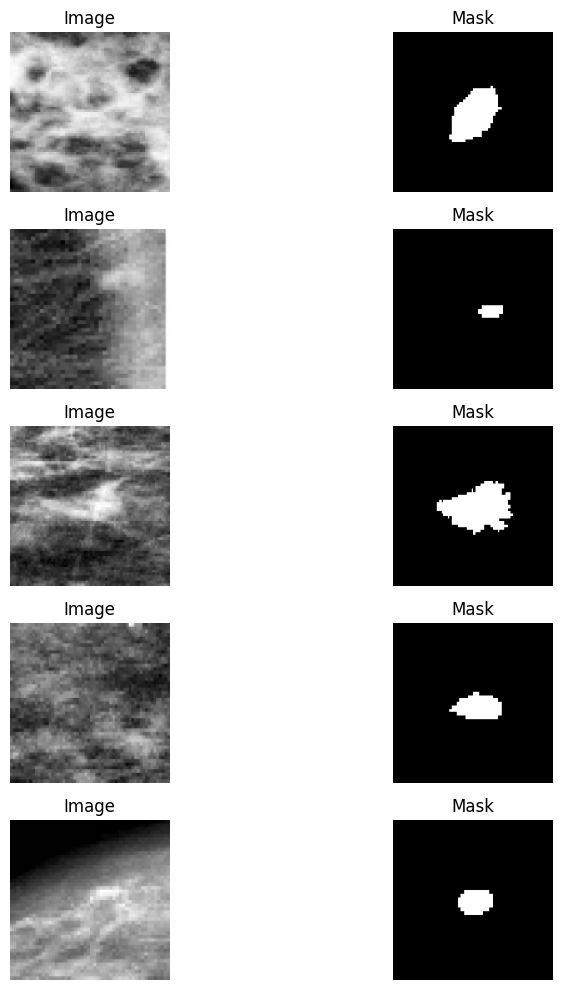

In [9]:
import matplotlib.pyplot as plt
import random

plt.figure(figsize=(10, 10))

for i in range(5):
    idx = random.randint(0, len(X)-1)

    plt.subplot(5, 2, 2*i+1)
    plt.imshow(X[idx].squeeze(), cmap="gray")
    plt.title("Image")
    plt.axis("off")

    plt.subplot(5, 2, 2*i+2)
    plt.imshow(Y[idx].squeeze(), cmap="gray")
    plt.title("Mask")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
# PART 2 : IMPORT LIBRARIES

from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

In [12]:
# TRAIN / VALIDATION / TEST SPLIT

X_train, X_temp, Y_train, Y_temp = train_test_split(
    X,
    Y,
    test_size=0.30,
    random_state=SEED,
    shuffle=True
)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.50,
    random_state=SEED,
    shuffle=True
)

print(f"Training Images   : {len(X_train)}")
print(f"Validation Images : {len(X_val)}")
print(f"Testing Images    : {len(X_test)}")

Training Images   : 2269
Validation Images : 486
Testing Images    : 487


In [13]:
# CUSTOM PYTORCH DATASET
class BreastCancerDataset(Dataset):

    def __init__(self, images, masks):
        self.images = images
        self.masks = masks

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):

        image = self.images[index]
        mask = self.masks[index]

        # Convert NumPy -> Torch Tensor
        image = torch.from_numpy(image).float()
        mask = torch.from_numpy(mask).float()

        # Convert HWC -> CHW
        image = image.permute(2, 0, 1)
        mask = mask.permute(2, 0, 1)

        return image, mask

In [14]:
# CREATE DATASETS

train_dataset = BreastCancerDataset(X_train, Y_train)
val_dataset = BreastCancerDataset(X_val, Y_val)
test_dataset = BreastCancerDataset(X_test, Y_test)

In [15]:
# CREATE DATALOADERS

BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [16]:
# VERIFY DATALOADER

images, masks = next(iter(train_loader))

print(f"Images Shape : {images.shape}")
print(f"Masks Shape  : {masks.shape}")

print(f"Image dtype  : {images.dtype}")
print(f"Mask dtype   : {masks.dtype}")

print(f"Device       : {DEVICE}")

Images Shape : torch.Size([8, 1, 128, 128])
Masks Shape  : torch.Size([8, 1, 128, 128])
Image dtype  : torch.float32
Mask dtype   : torch.float32
Device       : cuda


In [17]:
# RESIDUAL BLOCK

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv_block = nn.Sequential(

            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels)

        )

        self.shortcut = nn.Sequential()

        if in_channels != out_channels:

            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = self.shortcut(x)
        x = self.conv_block(x)
        x = x + residual
        x = self.relu(x)
        return x

In [18]:
# ENCODER BLOCK

class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.residual = ResidualBlock(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2)

    def forward(self, x):
        features = self.residual(x)
        pooled = self.pool(features)
        return features, pooled

In [19]:
# DECODER BLOCK

class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.residual = ResidualBlock(
            out_channels + skip_channels,
            out_channels
        )

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        x = self.residual(x)
        return x

In [20]:
# ORIGINAL RESUNET

class ResUNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.e1 = EncoderBlock(1, 32)
        self.e2 = EncoderBlock(32, 64)
        self.e3 = EncoderBlock(64, 128)
        self.e4 = EncoderBlock(128, 256)

        # Bridge
        self.bridge = ResidualBlock(256, 512)

        # Decoder
        self.d4 = DecoderBlock(512, 256, 256)
        self.d3 = DecoderBlock(256, 128, 128)
        self.d2 = DecoderBlock(128, 64, 64)
        self.d1 = DecoderBlock(64, 32, 32)

        # Output
        self.output = nn.Conv2d(
            32,
            1,
            kernel_size=1
        )

    def forward(self, x):

        s1, p1 = self.e1(x)
        s2, p2 = self.e2(p1)
        s3, p3 = self.e3(p2)
        s4, p4 = self.e4(p3)

        b = self.bridge(p4)

        d4 = self.d4(b, s4)
        d3 = self.d3(d4, s3)
        d2 = self.d2(d3, s2)
        d1 = self.d1(d2, s1)

        out = self.output(d1)

        return out

In [21]:
# INITIALIZE MODEL

model = ResUNet().to(DEVICE)

print(model)

ResUNet(
  (e1): EncoderBlock(
    (residual): ResidualBlock(
      (conv_block): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (shortcut): Sequential(
        (0): Conv2d(1, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (relu): ReLU(inplace=True)
    )
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (e2): EncoderBlock(
    (residual): ResidualBlock(
      (conv_block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), 

In [22]:
# VERIFY MODEL
images, masks = next(iter(train_loader))
images = images.to(DEVICE)

with torch.no_grad():
    outputs = model(images)

print("Input Shape :", images.shape)
print("Output Shape:", outputs.shape)

Input Shape : torch.Size([8, 1, 128, 128])
Output Shape: torch.Size([8, 1, 128, 128])


In [23]:
# MODEL PARAMETERS

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

Total Parameters     : 8,113,601
Trainable Parameters : 8,113,601


In [24]:
# PART 4 : LOSS FUNCTIONS & METRICS

import torch.nn.functional as F

In [25]:
# DICE COEFFICIENT

def dice_coefficient(pred, target, smooth=1e-6):
    """
    Computes Dice Score.

    Parameters:
        pred   : Model predictions
        target : Ground truth mask

    Returns:
        Dice coefficient
    """

    pred = pred.contiguous().view(-1)
    target = target.contiguous().view(-1)

    intersection = (pred * target).sum()

    dice = (2.0 * intersection + smooth) / (
        pred.sum() + target.sum() + smooth
    )

    return dice

In [26]:
# INTERSECTION OVER UNION

def iou_score(pred, target, smooth=1e-6):
    """
    Computes IoU Score.
    """

    pred = pred.contiguous().view(-1)
    target = target.contiguous().view(-1)

    intersection = (pred * target).sum()

    union = pred.sum() + target.sum() - intersection

    iou = (intersection + smooth) / (union + smooth)

    return iou

In [27]:
# DICE LOSS

class DiceLoss(nn.Module):

    def __init__(self):
        super().__init__()

    def forward(self, pred, target):

        dice = dice_coefficient(pred, target)

        return 1 - dice

In [28]:
class BCEDiceLoss(nn.Module):

    def __init__(self):
        super().__init__()

        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, pred, target):

        bce_loss = self.bce(pred, target)

        # Apply sigmoid only for Dice computation
        pred = torch.sigmoid(pred)

        dice_loss = self.dice(pred, target)

        return bce_loss + dice_loss

In [29]:
# LOSS FUNCTION

criterion = BCEDiceLoss()

print("Loss Function Initialized Successfully!")

Loss Function Initialized Successfully!


In [30]:
# METRICS HELPER FUNCTION
def calculate_metrics(outputs, masks):
    predictions = (torch.sigmoid(outputs) > 0.5).float()

    dice = dice_coefficient(predictions, masks)
    iou = iou_score(predictions, masks)

    return dice.item(), iou.item()

In [31]:
# VERIFY LOSS FUNCTION

images, masks = next(iter(train_loader))

images = images.to(DEVICE)
masks = masks.to(DEVICE)

with torch.no_grad():
    outputs = model(images)

loss = criterion(outputs, masks)

dice, iou = calculate_metrics(outputs, masks)

print(f"Loss : {loss:.4f}")
print(f"Dice : {dice:.4f}")
print(f"IoU  : {iou:.4f}")

Loss : 1.5006
Dice : 0.1691
IoU  : 0.0924


In [32]:
# PART 5 : TRAINING SETUP

import copy
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.cuda.amp import GradScaler

In [33]:
# TRAINING HYPERPARAMETERS

LEARNING_RATE = 1e-3
NUM_EPOCHS = 50

PATIENCE = 10

MODEL_PATH = "best_resunet.pth"

In [34]:
# OPTIMIZER

optimizer = Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

In [35]:
# LEARNING RATE SCHEDULER

scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

In [36]:
# MIXED PRECISION

scaler = GradScaler(enabled=torch.cuda.is_available())

print("Mixed Precision:", torch.cuda.is_available())

Mixed Precision: True


In [37]:
# EARLY STOPPING

class EarlyStopping:

    def __init__(self, patience=10):

        self.patience = patience
        self.counter = 0

        self.best_loss = float("inf")

        self.early_stop = False

    def __call__(self, val_loss):

        if val_loss < self.best_loss:

            self.best_loss = val_loss
            self.counter = 0

        else:

            self.counter += 1

            print(f"EarlyStopping Counter: {self.counter}/{self.patience}")

            if self.counter >= self.patience:

                self.early_stop = True

In [38]:
# INITIALIZE EARLY STOPPING

early_stopping = EarlyStopping(
    patience=PATIENCE
)

In [39]:
# TRAINING HISTORY

history = {

    "train_loss": [],
    "val_loss": [],

    "train_dice": [],
    "val_dice": [],

    "train_iou": [],
    "val_iou": []

}

In [40]:
# SAVE BEST MODEL

best_val_loss = float("inf")

def save_best_model(model, val_loss):

    global best_val_loss

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(model.state_dict(), MODEL_PATH)

        print(f"Best model saved! Validation Loss: {val_loss:.4f}")

In [41]:
# VERIFY TRAINING SETUP

print("Optimizer      :", optimizer.__class__.__name__)
print("Scheduler      :", scheduler.__class__.__name__)
print("Loss Function  :", criterion.__class__.__name__)
print("Device         :", DEVICE)

Optimizer      : Adam
Scheduler      : ReduceLROnPlateau
Loss Function  : BCEDiceLoss
Device         : cuda


In [42]:
# PART 6 : TRAINING LOOP

from tqdm.auto import tqdm

In [43]:
# TRAIN ONE EPOCH

def train_one_epoch(model, loader, optimizer, criterion, scaler, device):

    model.train()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, masks in progress_bar:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        if device.type == "cuda":

            with torch.cuda.amp.autocast():

                outputs = model(images)
                loss = criterion(outputs, masks)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        else:

            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

        dice, iou = calculate_metrics(outputs, masks)

        running_loss += loss.item()
        running_dice += dice
        running_iou += iou

        progress_bar.set_postfix(
            Loss=f"{loss.item():.4f}",
            Dice=f"{dice:.4f}",
            IoU=f"{iou:.4f}"
        )

    return (
        running_loss / len(loader),
        running_dice / len(loader),
        running_iou / len(loader)
    )

In [44]:
# VALIDATE ONE EPOCH

def validate_one_epoch(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0

    with torch.no_grad():

        progress_bar = tqdm(loader, desc="Validation", leave=False)

        for images, masks in progress_bar:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)

            dice, iou = calculate_metrics(outputs, masks)

            running_loss += loss.item()
            running_dice += dice
            running_iou += iou

            progress_bar.set_postfix(
                Loss=f"{loss.item():.4f}",
                Dice=f"{dice:.4f}",
                IoU=f"{iou:.4f}"
            )

    return (
        running_loss / len(loader),
        running_dice / len(loader),
        running_iou / len(loader)
    )

In [45]:
# TRAIN MODEL

best_val_loss = float("inf")

for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
    print("-" * 60)

    train_loss, train_dice, train_iou = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        scaler,
        DEVICE
    )

    val_loss, val_dice, val_iou = validate_one_epoch(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_dice"].append(train_dice)
    history["val_dice"].append(val_dice)

    history["train_iou"].append(train_iou)
    history["val_iou"].append(val_iou)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")

    print(f"Train Dice : {train_dice:.4f}")
    print(f"Val Dice   : {val_dice:.4f}")

    print(f"Train IoU  : {train_iou:.4f}")
    print(f"Val IoU    : {val_iou:.4f}")

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(model.state_dict(), MODEL_PATH)

        print("Best model saved!")

    early_stopping(val_loss)

    if early_stopping.early_stop:

        print("\nEarly stopping triggered!")

        break

print("\nTraining Completed Successfully!")


Epoch [1/50]
------------------------------------------------------------


Training:   0%|          | 0/284 [00:00<?, ?it/s]

Validation:   0%|          | 0/61 [00:00<?, ?it/s]

Train Loss : 0.5504
Val Loss   : 0.4859
Train Dice : 0.6933
Val Dice   : 0.6997
Train IoU  : 0.5436
Val IoU    : 0.5402
Best model saved!

Epoch [2/50]
------------------------------------------------------------


Training:   0%|          | 0/284 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/61 [00:00<?, ?it/s]

Train Loss : 0.1132
Val Loss   : 0.2978
Train Dice : 0.9275
Val Dice   : 0.8243
Train IoU  : 0.8652
Val IoU    : 0.7033
EarlyStopping Counter: 9/10

Epoch [32/50]
------------------------------------------------------------


Training:   0%|          | 0/284 [00:00<?, ?it/s]

Validation:   0%|          | 0/61 [00:00<?, ?it/s]

Train Loss : 0.1096
Val Loss   : 0.3008
Train Dice : 0.9300
Val Dice   : 0.8239
Train IoU  : 0.8695
Val IoU    : 0.7028
EarlyStopping Counter: 10/10

Early stopping triggered!

Training Completed Successfully!


In [46]:
# ==========================================================
# PART 7 : LOAD BEST MODEL
# ==========================================================

model = ResUNet().to(DEVICE)

model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))

model.eval()

print("Best model loaded successfully!")

Best model loaded successfully!


In [47]:
# ==========================================================
# TEST FUNCTION
# ==========================================================

def test_model(model, loader, criterion, device):

    model.eval()

    test_loss = 0.0
    test_dice = 0.0
    test_iou = 0.0

    with torch.no_grad():

        progress_bar = tqdm(loader, desc="Testing")

        for images, masks in progress_bar:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)

            dice, iou = calculate_metrics(outputs, masks)

            test_loss += loss.item()
            test_dice += dice
            test_iou += iou

    test_loss /= len(loader)
    test_dice /= len(loader)
    test_iou /= len(loader)

    return test_loss, test_dice, test_iou

In [48]:
# ==========================================================
# EVALUATE MODEL
# ==========================================================

test_loss, test_dice, test_iou = test_model(
    model,
    test_loader,
    criterion,
    DEVICE
)

print("="*60)

print(f"Test Loss : {test_loss:.4f}")
print(f"Test Dice : {test_dice:.4f}")
print(f"Test IoU  : {test_iou:.4f}")

print("="*60)

Testing:   0%|          | 0/61 [00:00<?, ?it/s]

Test Loss : 0.2868
Test Dice : 0.8244
Test IoU  : 0.7035


In [49]:
# ==========================================================
# SAVE RESULTS
# ==========================================================

results = {
    "Test Loss": test_loss,
    "Test Dice": test_dice,
    "Test IoU": test_iou
}

print(results)

{'Test Loss': 0.2868233284012216, 'Test Dice': 0.824364718843679, 'Test IoU': 0.703494237094629}


In [50]:
# PART 8 : VISUALIZATION

import matplotlib.pyplot as plt
import random

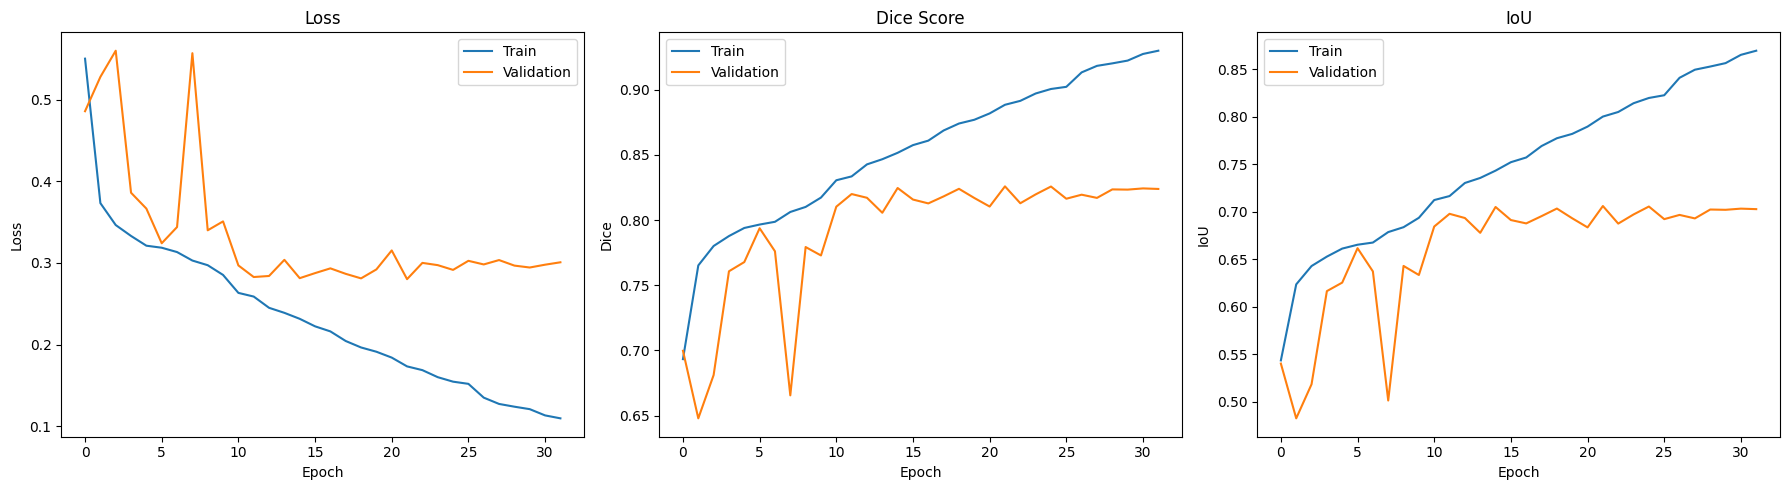

In [51]:
# TRAINING CURVES

plt.figure(figsize=(18,5))

# Loss
plt.subplot(1,3,1)
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Dice
plt.subplot(1,3,2)
plt.plot(history["train_dice"], label="Train")
plt.plot(history["val_dice"], label="Validation")
plt.title("Dice Score")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.legend()

# IoU
plt.subplot(1,3,3)
plt.plot(history["train_iou"], label="Train")
plt.plot(history["val_iou"], label="Validation")
plt.title("IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.legend()

plt.tight_layout()
plt.show()

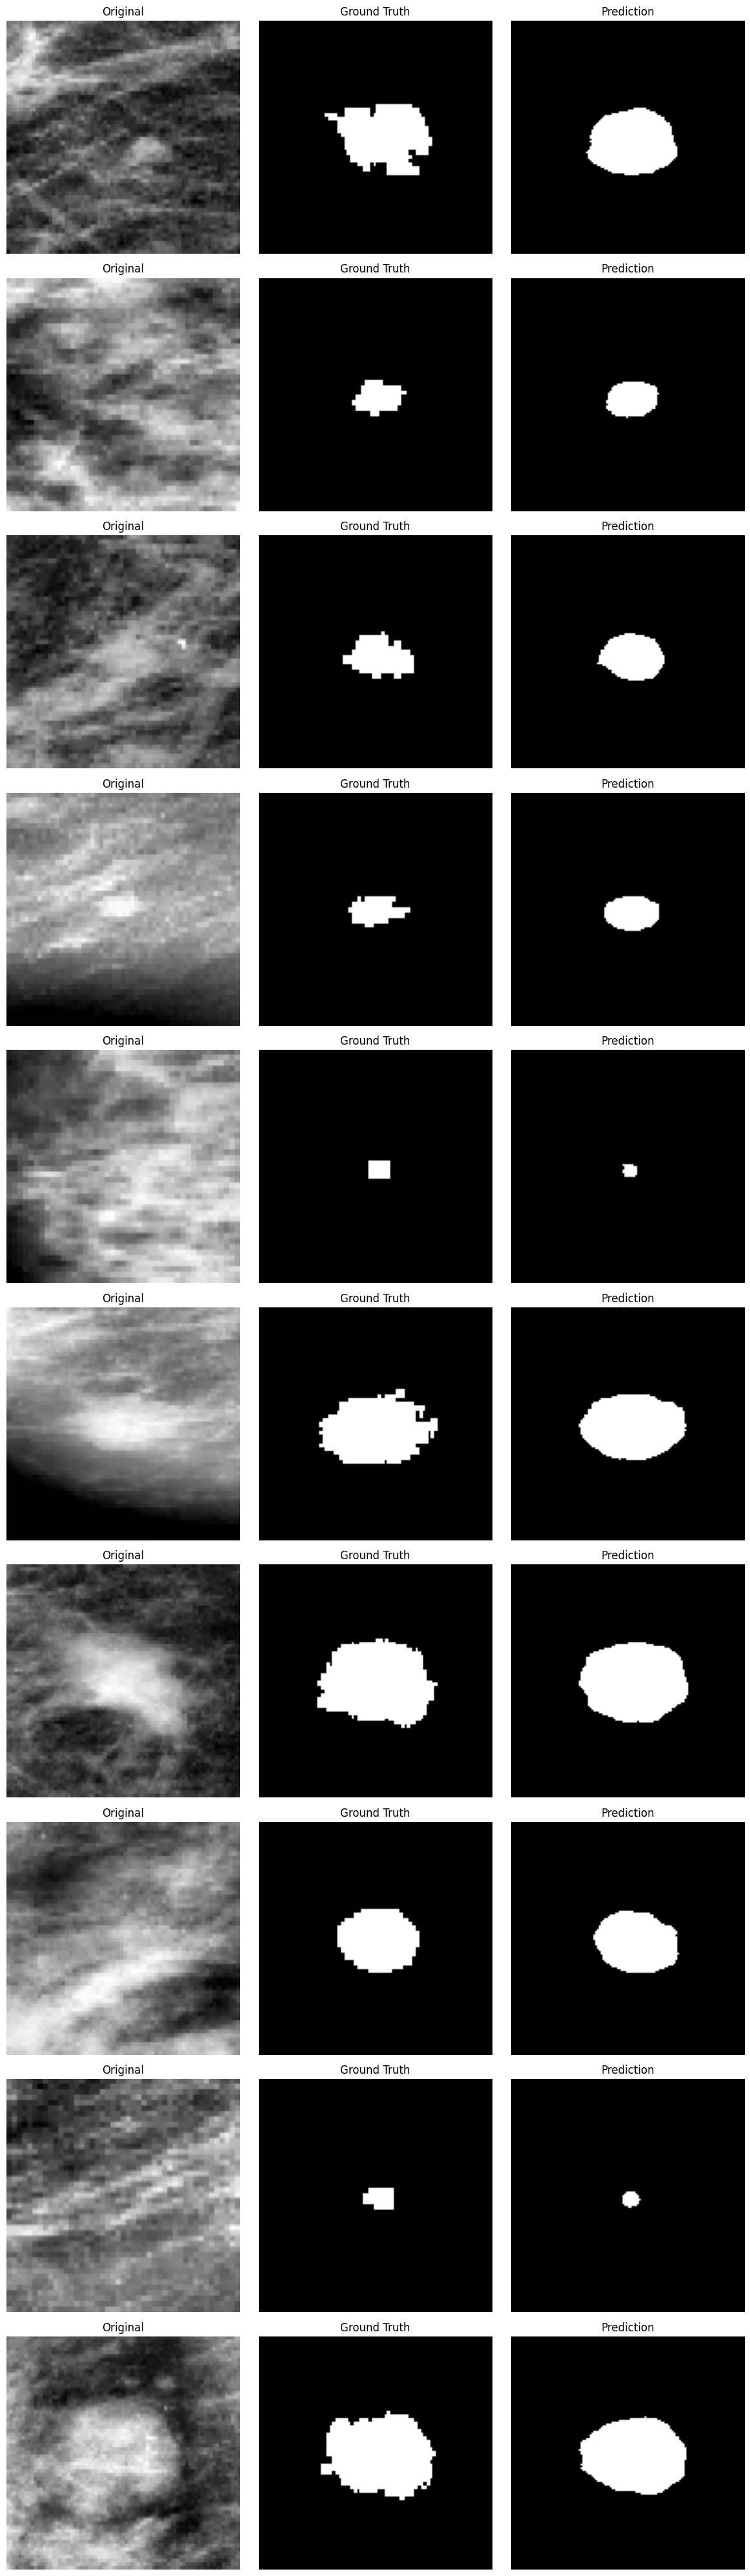

In [52]:
# VISUALIZE TEST PREDICTIONS

model.eval()

NUM_SAMPLES = 10

indices = random.sample(range(len(test_dataset)), NUM_SAMPLES)

plt.figure(figsize=(12, NUM_SAMPLES*4))

for i, idx in enumerate(indices):

    image, mask = test_dataset[idx]

    input_tensor = image.unsqueeze(0).to(DEVICE)

    with torch.no_grad():

        output = model(input_tensor)

        prediction = (torch.sigmoid(output) > 0.5).float()

    image = image.squeeze().cpu().numpy()
    mask = mask.squeeze().cpu().numpy()
    prediction = prediction.squeeze().cpu().numpy()

    # Original Image
    plt.subplot(NUM_SAMPLES,3,3*i+1)
    plt.imshow(image, cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Ground Truth
    plt.subplot(NUM_SAMPLES,3,3*i+2)
    plt.imshow(mask, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    # Prediction
    plt.subplot(NUM_SAMPLES,3,3*i+3)
    plt.imshow(prediction, cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

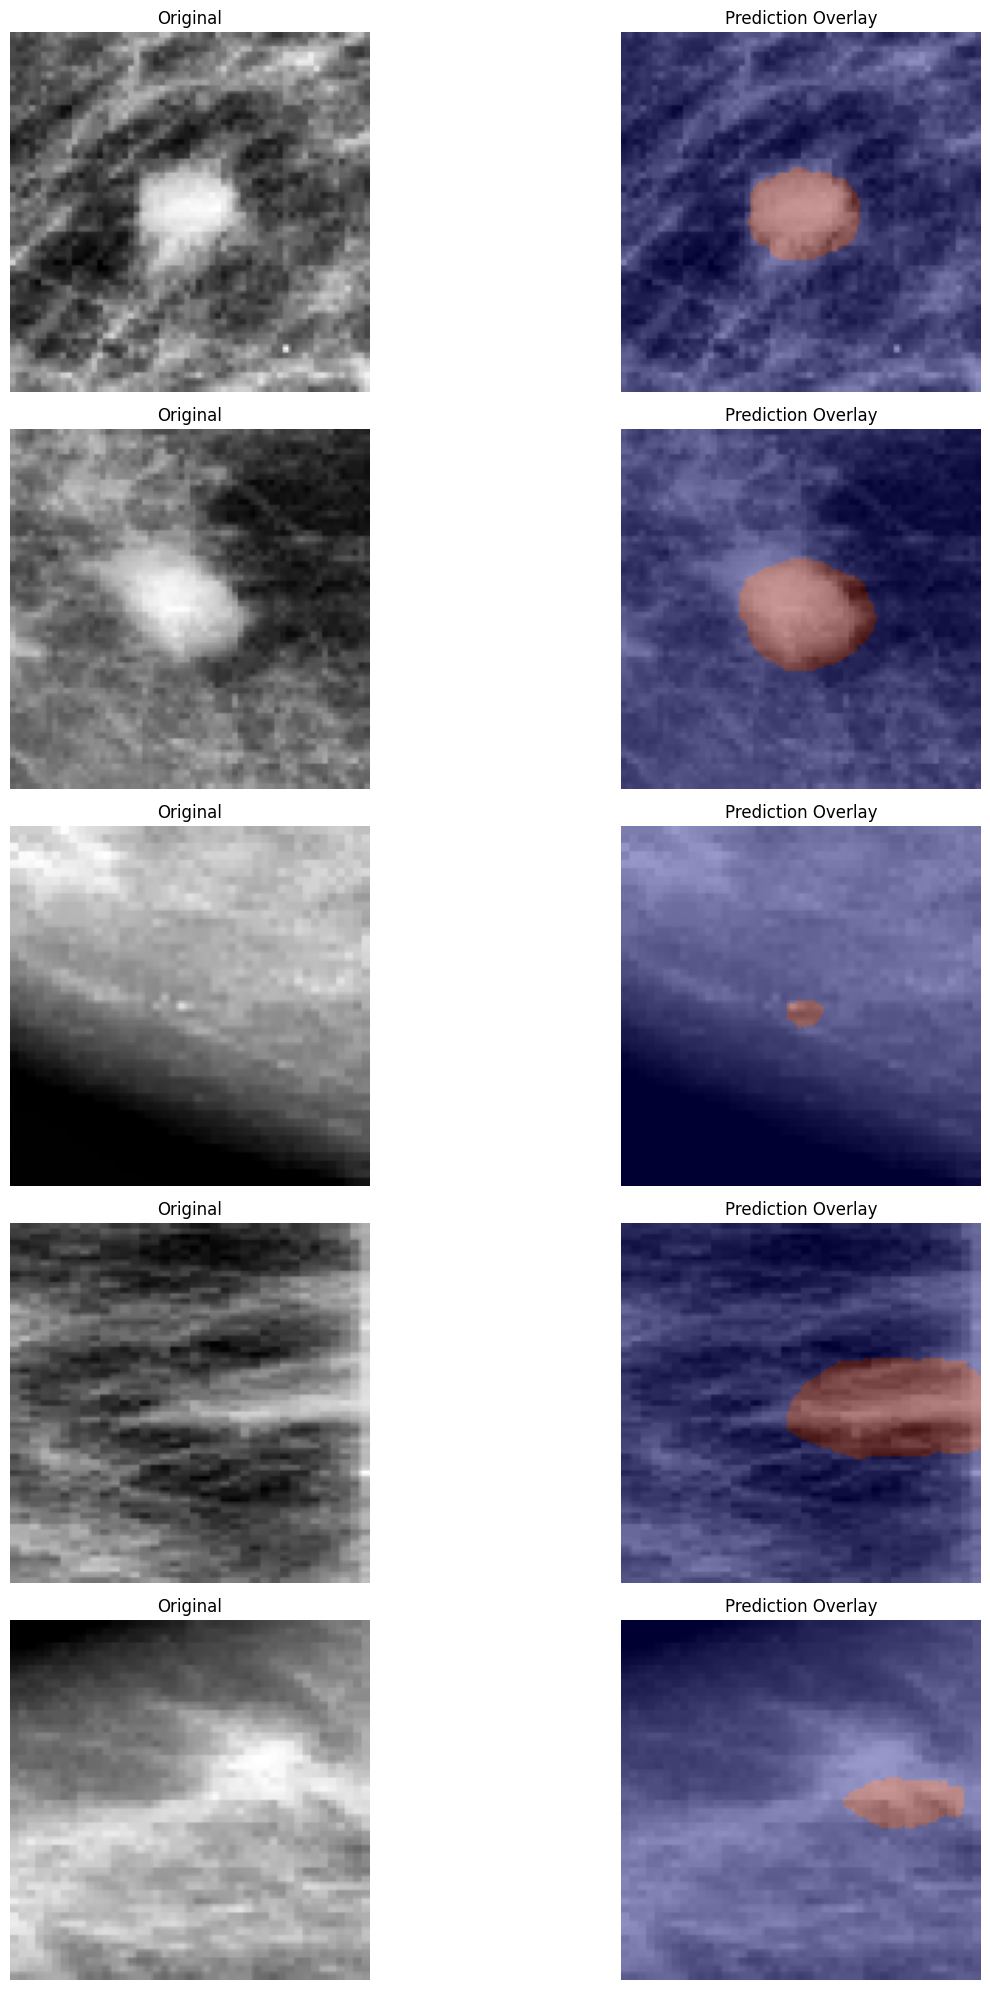

In [53]:
# ==========================================================
# OVERLAY PREDICTIONS
# ==========================================================

NUM_SAMPLES = 5

indices = random.sample(range(len(test_dataset)), NUM_SAMPLES)

plt.figure(figsize=(15, NUM_SAMPLES*4))

for i, idx in enumerate(indices):

    image, mask = test_dataset[idx]

    image_np = image.squeeze().numpy()

    with torch.no_grad():
        output = model(image.unsqueeze(0).to(DEVICE))
        prediction = (torch.sigmoid(output) > 0.5).float().squeeze().cpu().numpy()

    # Original
    plt.subplot(NUM_SAMPLES,2,2*i+1)
    plt.imshow(image_np, cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Overlay
    plt.subplot(NUM_SAMPLES,2,2*i+2)
    plt.imshow(image_np, cmap="gray")
    plt.imshow(prediction, cmap="jet", alpha=0.4)
    plt.title("Prediction Overlay")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [56]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

In [57]:
def evaluate_model(model, loader, criterion, device):

    model.eval()

    total_loss = 0
    total_dice = 0
    total_iou = 0

    all_preds = []
    all_masks = []

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)

            predictions = (torch.sigmoid(outputs) > 0.5).float()

            dice = dice_coefficient(predictions, masks)
            iou = iou_score(predictions, masks)

            total_loss += loss.item()
            total_dice += dice.item()
            total_iou += iou.item()

            all_preds.extend(predictions.cpu().numpy().flatten())
            all_masks.extend(masks.cpu().numpy().flatten())

    precision = precision_score(
        all_masks,
        all_preds,
        zero_division=0
    )

    recall = recall_score(
        all_masks,
        all_preds,
        zero_division=0
    )

    f1 = f1_score(
        all_masks,
        all_preds,
        zero_division=0
    )

    results = {
        "Loss": total_loss / len(loader),
        "Dice": total_dice / len(loader),
        "IoU": total_iou / len(loader),
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

    return results

In [58]:
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

ResUNet(
  (e1): EncoderBlock(
    (residual): ResidualBlock(
      (conv_block): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (shortcut): Sequential(
        (0): Conv2d(1, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (relu): ReLU(inplace=True)
    )
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (e2): EncoderBlock(
    (residual): ResidualBlock(
      (conv_block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), 

In [59]:
train_results = evaluate_model(
    model,
    train_loader,
    criterion,
    DEVICE
)

val_results = evaluate_model(
    model,
    val_loader,
    criterion,
    DEVICE
)

test_results = evaluate_model(
    model,
    test_loader,
    criterion,
    DEVICE
)

In [62]:
import pandas as pd

results_df = pd.DataFrame({
    "Metric": ["Loss", "Dice", "IoU", "Precision", "Recall", "F1 Score"],
    "Train": [
        train_results["Loss"],
        train_results["Dice"],
        train_results["IoU"],
        train_results["Precision"],
        train_results["Recall"],
        train_results["F1 Score"]
    ],
    "Validation": [
        val_results["Loss"],
        val_results["Dice"],
        val_results["IoU"],
        val_results["Precision"],
        val_results["Recall"],
        val_results["F1 Score"]
    ],
    "Test": [
        test_results["Loss"],
        test_results["Dice"],
        test_results["IoU"],
        test_results["Precision"],
        test_results["Recall"],
        test_results["F1 Score"]
    ]
})

# Round to 4 decimal places
results_df = results_df.round(4)

# Display as a nice table
display(results_df)

,Metric,Train,Validation,Test
0,Loss,0.1616,0.2801,0.2868
1,Dice,0.8965,0.8259,0.8244
2,IoU,0.8129,0.7061,0.7035
3,Precision,0.8793,0.8024,0.8245
4,Recall,0.9193,0.8485,0.8220
5,F1 Score,0.8989,0.8248,0.8233


In [63]:
#Save Model
torch.save(model.state_dict(), "ResUNet_CBIS_DDSM_Best.pth")